In [ ]:
!pip install -q implicit pandas numpy scipy scikit-learn tqdm

In [ ]:
import os

import pandas as pd
import numpy as np

from google.colab import drive

from scipy.sparse import csr_matrix
from implicit.als import AlternatingLeastSquares

from tqdm import tqdm

In [ ]:
drive.mount('/content/drive')

BASE_PATH = "/content/drive/MyDrive/courseproject"
os.chdir(BASE_PATH)

print("Current dir:", os.getcwd())
print("Files:", os.listdir())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Current dir: /content/drive/MyDrive/courseproject
Files: ['Screenshot_4.png', 'submissions_archive_2026-04-09.zip', 'user_practice_submissions.csv', 'README.txt', 'micromodules_competencies.csv', 'task_competence_mapping.csv', 'user_competences.csv', 'user_task_submissions.csv', 'user_competences_20260409.csv', 'user_competences_20260331.csv', 'User Competence.csv']


In [ ]:
AGG_MATRIX_PATH = "User Competence.csv"
MICRO_MODULES_PATH = "micromodules_competencies.csv"

USER_COMP_OLD_PATH = "user_competences_20260331.csv"
USER_COMP_NEW_PATH = "user_competences_20260409.csv"

In [ ]:
agg_df = pd.read_csv(AGG_MATRIX_PATH, sep=";", encoding="utf-8-sig")
micro_df = pd.read_csv(MICRO_MODULES_PATH, sep=";", encoding="utf-8-sig")

uc_old = pd.read_csv(USER_COMP_OLD_PATH, sep=";", encoding="utf-8-sig")
uc_new = pd.read_csv(USER_COMP_NEW_PATH, sep=";", encoding="utf-8-sig")

print("Aggregated matrix:", agg_df.shape)
print("Micro modules:", micro_df.shape)
print("User competences old:", uc_old.shape)
print("User competences new:", uc_new.shape)

display(agg_df.head())

Aggregated matrix: (1261, 4)
Micro modules: (1038, 11)
User competences old: (6809, 11)
User competences new: (7100, 11)


,user_id,user_number,competence_id,activated_metric
0,0e24ff0e-c58a-4a6c-b054-e80df6607b99,2,0092b753-5923-4b1f-b958-87d133d8a040,0.666667
1,17993c65-1f0e-4f0a-b458-a7c688b99ea0,3,0092b753-5923-4b1f-b958-87d133d8a040,0.375000
2,363f7164-3a52-43aa-8b9b-b1677ed218ec,5,0092b753-5923-4b1f-b958-87d133d8a040,0.571429
3,3f0b3f70-360a-4b6e-a96b-58306b6d98e8,7,0092b753-5923-4b1f-b958-87d133d8a040,0.750000
4,41cbf776-e9ce-4752-85f6-480ae5127777,8,0092b753-5923-4b1f-b958-87d133d8a040,0.750000


In [ ]:
print("AGG columns:")
print(agg_df.columns.tolist())

print("\nMICRO columns:")
print(micro_df.columns.tolist())

print("\nUSER_COMP columns:")
print(uc_old.columns.tolist())

AGG columns:
['user_id', 'user_number', 'competence_id', 'activated_metric']

MICRO columns:
['namespace_id', 'namespace_name', 'course_id', 'task_number', 'course_description', 'node_id', 'node_name', 'competence_id', 'competence_code', 'competence_name', 'importance']

USER_COMP columns:
['user_id', 'user_number', 'competence_id', 'competence_code', 'competence_name', 'probability', 'assessment_source', 'evidence_count', 'assessed_at', 'valid_from', 'valid_to']


In [ ]:
agg_long = agg_df.copy()

agg_long["activated_metric"] = pd.to_numeric(
    agg_long["activated_metric"],
    errors="coerce"
)

agg_long = agg_long.dropna(subset=["activated_metric"])
agg_long = agg_long[agg_long["activated_metric"] > 0].copy()

print("Rows:", len(agg_long))
print("Users:", agg_long["user_id"].nunique())
print("Competences:", agg_long["competence_id"].nunique())

display(agg_long.head())

Rows: 1261
Users: 33
Competences: 98


,user_id,user_number,competence_id,activated_metric
0,0e24ff0e-c58a-4a6c-b054-e80df6607b99,2,0092b753-5923-4b1f-b958-87d133d8a040,0.666667
1,17993c65-1f0e-4f0a-b458-a7c688b99ea0,3,0092b753-5923-4b1f-b958-87d133d8a040,0.375000
2,363f7164-3a52-43aa-8b9b-b1677ed218ec,5,0092b753-5923-4b1f-b958-87d133d8a040,0.571429
3,3f0b3f70-360a-4b6e-a96b-58306b6d98e8,7,0092b753-5923-4b1f-b958-87d133d8a040,0.750000
4,41cbf776-e9ce-4752-85f6-480ae5127777,8,0092b753-5923-4b1f-b958-87d133d8a040,0.750000


In [ ]:
# берём последнее известное значение probability по каждой паре user_id + competence_id в каждой из двух выгрузок.

uc_old_last = (
    uc_old.sort_values("evidence_count")
    .groupby(["user_id", "competence_id"], as_index=False)
    .last()
)

uc_new_last = (
    uc_new.sort_values("evidence_count")
    .groupby(["user_id", "competence_id"], as_index=False)
    .last()
)

trend_df = uc_old_last.merge(
    uc_new_last,
    on=["user_id", "competence_id"],
    suffixes=("_old", "_new"),
    how="inner"
)

trend_df["competence_trend"] = (
    trend_df["probability_new"] - trend_df["probability_old"]
)

trend_df = trend_df[[
    "user_id",
    "competence_id",
    "probability_old",
    "probability_new",
    "competence_trend"
]]

display(trend_df.head())
print("Trend rows:", trend_df.shape)
print("Users with trend:", trend_df["user_id"].nunique())
print("Competences with trend:", trend_df["competence_id"].nunique())

,user_id,competence_id,probability_old,probability_new,competence_trend
0,04faac8a-55ba-45e8-b22b-3defa5512390,078423e2-9dcd-4e8e-9887-702ee08b0153,0.956498,0.956498,0.0
1,04faac8a-55ba-45e8-b22b-3defa5512390,1024e3ec-6786-4059-84fe-3ae001527444,0.035088,0.035088,0.0
2,04faac8a-55ba-45e8-b22b-3defa5512390,118d8585-a00f-46f7-be45-0a39fc33f401,0.115756,0.115756,0.0
3,04faac8a-55ba-45e8-b22b-3defa5512390,2e7f87eb-5a14-4b20-99f4-7efc507e829b,0.629160,0.629160,0.0
4,04faac8a-55ba-45e8-b22b-3defa5512390,2f810ad4-1d9a-47a2-ac2a-54f8d6c46692,0.035088,0.035088,0.0


Trend rows: (931, 5)
Users with trend: 29
Competences with trend: 92


In [ ]:
agg_long = agg_long.merge(
    trend_df[["user_id", "competence_id", "competence_trend"]],
    on=["user_id", "competence_id"],
    how="left"
)

agg_long["competence_trend"] = agg_long["competence_trend"].fillna(0)

display(agg_long[[
    "user_id",
    "competence_id",
    "activated_metric",
    "competence_trend"
]].head())

print("Rows total:", len(agg_long))
print("Rows with non-zero trend:", (agg_long["competence_trend"] != 0).sum())
print("Share with non-zero trend:", (agg_long["competence_trend"] != 0).mean())

,user_id,competence_id,activated_metric,competence_trend
0,0e24ff0e-c58a-4a6c-b054-e80df6607b99,0092b753-5923-4b1f-b958-87d133d8a040,0.666667,0.000000
1,17993c65-1f0e-4f0a-b458-a7c688b99ea0,0092b753-5923-4b1f-b958-87d133d8a040,0.375000,-0.017933
2,363f7164-3a52-43aa-8b9b-b1677ed218ec,0092b753-5923-4b1f-b958-87d133d8a040,0.571429,0.000000
3,3f0b3f70-360a-4b6e-a96b-58306b6d98e8,0092b753-5923-4b1f-b958-87d133d8a040,0.750000,0.000000
4,41cbf776-e9ce-4752-85f6-480ae5127777,0092b753-5923-4b1f-b958-87d133d8a040,0.750000,0.000000


Rows total: 1261
Rows with non-zero trend: 167
Share with non-zero trend: 0.1324345757335448


In [ ]:
alpha = 0.3

agg_long["trend_activated_metric"] = (
    agg_long["activated_metric"] * (1 + alpha * agg_long["competence_trend"])
)

agg_long["trend_activated_metric"] = agg_long["trend_activated_metric"].clip(lower=0)

agg_long[[
    "activated_metric",
    "competence_trend",
    "trend_activated_metric"
]].describe()

print("Mean activated_metric:", agg_long["activated_metric"].mean())
print("Mean trend_activated_metric:", agg_long["trend_activated_metric"].mean())

print(
    "Rows where metric changed:",
    (agg_long["activated_metric"] != agg_long["trend_activated_metric"]).sum()
)

Mean activated_metric: 0.6096759665349295
Mean trend_activated_metric: 0.6116159204506714
Rows where metric changed: 167


Построение матрицы пользователь × компетенция

In [ ]:
def build_sparse_matrix(df, value_col):
    users = df["user_id"].astype("category")
    comps = df["competence_id"].astype("category")

    user_index = users.cat.categories
    comp_index = comps.cat.categories

    rows = users.cat.codes
    cols = comps.cat.codes

    matrix = csr_matrix(
        (
            df[value_col].astype(float),
            (rows, cols)
        ),
        shape=(len(user_index), len(comp_index))
    )

    return matrix, user_index, comp_index

### Построение матрицы

Формируется матрица на основе метрики trend_activated_metric, которая учитывает исходную activated_metric и тренд изменения probability по компетенции.


In [ ]:
agg_matrix, agg_users, agg_comp = build_sparse_matrix(
    agg_long,
    "trend_activated_metric"
)

print("agg_matrix:", agg_matrix.shape)
print("Users in matrix:", len(agg_users))
print("Competences in matrix:", len(agg_comp))
print("Matrix non-zero values:", agg_matrix.nnz)

agg_matrix: (33, 98)
Users in matrix: 33
Competences in matrix: 98
Matrix non-zero values: 1261


### Обучение модели ALS

In [ ]:
def train_als(matrix):
    model = AlternatingLeastSquares(
        factors=16,
        regularization=0.1,
        iterations=40,
        random_state=42
    )

    model.fit(matrix.tocsr())

    return model

### Обучение модели

Обучается ALS:
- на основе метрики trend_activated_metric
- эта метрика учитывает не только текущую активированную оценку, но и тренд изменения competence probability


In [ ]:
agg_model = train_als(agg_matrix)

  0%|          | 0/40 [00:00<?, ?it/s]

### Генерация рекомендаций компетенций на основе ALS-модели, обученной с учётом competence trend

Для каждого пользователя рекомендации формируются на основе обученной модели ALS.

Сначала извлекается латентный вектор пользователя (`user_factors`), после чего вычисляются оценки для всех компетенций как скалярное произведение пользовательского вектора и векторов компетенций (`item_factors`).


In [ ]:
def recommend_competences(
    model,
    matrix,
    user_idx,
    comp_index,
    n=30
):
    user_vec = model.user_factors[user_idx]

    scores = model.item_factors @ user_vec

    known = set(matrix[user_idx].indices)

    ids = np.argsort(-scores)

    result_ids = []
    result_scores = []

    for idx in ids:
        if idx not in known:
            result_ids.append(idx)
            result_scores.append(scores[idx])

        if len(result_ids) >= n:
            break

    return pd.DataFrame({
        "competence_id": comp_index[result_ids],
        "score": result_scores
    })

### Пример рекомендаций для пользователя

In [ ]:
sample_rec = recommend_competences(
    agg_model,
    agg_matrix,
    user_idx=0,
    comp_index=agg_comp,
    n=10
)

sample_rec

,competence_id,score
0,10a8e01b-d429-47d1-a81f-d71dcf486c7e,0.188317
1,52daaaea-fe2e-4886-8f7c-96331f287cd8,0.159476
2,485763a3-cee7-4128-bf6b-04b9da3bba38,0.158742
3,cab6fa63-cc7b-4063-82e3-42284be31eab,0.121497
4,73464e16-10af-44f7-846d-92148f12d6b8,0.090994
5,62c87b6c-eb4e-484e-af4f-b73d42ca4342,0.089768
6,2d3c34ea-d831-415a-9c6b-c36f255ef84c,0.089767
7,c77fb33b-de41-4aee-adee-da6a922b45f5,0.073442
8,53ee5d43-814c-4ce5-b664-0bb9730777bf,0.073419
9,8d11bcaf-582a-44e2-b216-0bacdf1cfb9f,0.072697


### Генерация рекомендаций для всех пользователей

In [ ]:
def recommend_all(
    model,
    matrix,
    users,
    comps,
    n=30
):
    rows = []

    for i in tqdm(range(matrix.shape[0])):
        rec = recommend_competences(
            model=model,
            matrix=matrix,
            user_idx=i,
            comp_index=comps,
            n=n
        )

        rec["user_id"] = users[i]
        rec["rank"] = np.arange(1, len(rec) + 1)

        rows.append(rec)

    return pd.concat(rows, ignore_index=True)

### Получение рекомендаций

Каждая строка таблицы содержит:
- `user_id` — пользователь
- `competence_id` — рекомендуемая компетенция
- `score` — оценка релевантности
- `rank` — позиция компетенции в топе рекомендаций

In [ ]:
agg_rec = recommend_all(
    agg_model,
    agg_matrix,
    agg_users,
    agg_comp,
    n=30
)

display(agg_rec.head())

100%|██████████| 33/33 [00:00<00:00, 805.04it/s]


,competence_id,score,user_id,rank
0,10a8e01b-d429-47d1-a81f-d71dcf486c7e,0.188317,04faac8a-55ba-45e8-b22b-3defa5512390,1
1,52daaaea-fe2e-4886-8f7c-96331f287cd8,0.159476,04faac8a-55ba-45e8-b22b-3defa5512390,2
2,485763a3-cee7-4128-bf6b-04b9da3bba38,0.158742,04faac8a-55ba-45e8-b22b-3defa5512390,3
3,cab6fa63-cc7b-4063-82e3-42284be31eab,0.121497,04faac8a-55ba-45e8-b22b-3defa5512390,4
4,73464e16-10af-44f7-846d-92148f12d6b8,0.090994,04faac8a-55ba-45e8-b22b-3defa5512390,5


In [ ]:
print("Competence recommendations shape:", agg_rec.shape)
print("Users in recommendations:", agg_rec["user_id"].nunique())
print("Recommended competences:", agg_rec["competence_id"].nunique())

Competence recommendations shape: (938, 7)
Users in recommendations: 33
Recommended competences: 97


In [ ]:
comp_names = (
    micro_df.groupby("competence_id", as_index=False)
    .agg(
        competence_name=("competence_name", "first"),
        course_description=("course_description", "first"),
        task_number=("task_number", "first")
    )
)

agg_rec = agg_rec.merge(
    comp_names,
    on="competence_id",
    how="left"
)

display(agg_rec.head())

,competence_id,score,user_id,rank,competence_name,course_description,task_number
0,10a8e01b-d429-47d1-a81f-d71dcf486c7e,0.188317,04faac8a-55ba-45e8-b22b-3defa5512390,1,Стереометрия,Стереометрия,3
1,52daaaea-fe2e-4886-8f7c-96331f287cd8,0.159476,04faac8a-55ba-45e8-b22b-3defa5512390,2,Умеет применять определение логарифма: logₐ(y)...,Простейшие уравнения,6
2,485763a3-cee7-4128-bf6b-04b9da3bba38,0.158742,04faac8a-55ba-45e8-b22b-3defa5512390,3,Умеет анализировать график функции и делать вы...,Производная,8
3,cab6fa63-cc7b-4063-82e3-42284be31eab,0.121497,04faac8a-55ba-45e8-b22b-3defa5512390,4,Умеет извлекать корень степени n из числа и вы...,Прикладные задачи,9
4,73464e16-10af-44f7-846d-92148f12d6b8,0.090994,04faac8a-55ba-45e8-b22b-3defa5512390,5,Умеет находить производную функции вида cos(x),Значения функций,12


In [ ]:
sample_user = agg_rec["user_id"].iloc[0]

agg_rec[
    agg_rec["user_id"] == sample_user
][[
    "rank",
    "competence_id",
    "competence_name",
    "course_description",
    "task_number",
    "score"
]].head(10)

,rank,competence_id,competence_name,course_description,task_number,score
0,1,10a8e01b-d429-47d1-a81f-d71dcf486c7e,Стереометрия,Стереометрия,3,0.188317
1,2,52daaaea-fe2e-4886-8f7c-96331f287cd8,Умеет применять определение логарифма: logₐ(y)...,Простейшие уравнения,6,0.159476
2,3,485763a3-cee7-4128-bf6b-04b9da3bba38,Умеет анализировать график функции и делать вы...,Производная,8,0.158742
3,4,cab6fa63-cc7b-4063-82e3-42284be31eab,Умеет извлекать корень степени n из числа и вы...,Прикладные задачи,9,0.121497
4,5,73464e16-10af-44f7-846d-92148f12d6b8,Умеет находить производную функции вида cos(x),Значения функций,12,0.090994
5,6,62c87b6c-eb4e-484e-af4f-b73d42ca4342,Умеет по описанию события для трёх испытаний о...,Теория Вероятностей,4,0.089768
6,7,2d3c34ea-d831-415a-9c6b-c36f255ef84c,Умеет выполнять полный перебор элементарных ис...,Теория Вероятностей,4,0.089767
7,8,c77fb33b-de41-4aee-adee-da6a922b45f5,"Умеет преобразовывать функцию, содержающую рад...",Значения функций,12,0.073442
8,9,53ee5d43-814c-4ce5-b664-0bb9730777bf,Умеет находить значение функции в точке экстре...,Значения функций,12,0.073419
9,10,8d11bcaf-582a-44e2-b216-0bacdf1cfb9f,Умеет находить точки экстремума функции по гра...,Производная,8,0.072697


In [ ]:
agg_rec.to_csv(
    "als_trend_aggregated_recommendations.csv",
    index=False,
    encoding="utf-8-sig"
)

## Переход от компетенций к микромодулям


In [ ]:
micro_comp = (
    micro_df[["node_id", "node_name", "competence_id"]]
    .dropna(subset=["node_id", "competence_id"])
    .drop_duplicates()
)

micro_dict = (
    micro_comp.groupby("node_id")["competence_id"]
    .apply(lambda x: set(x.astype(str)))
    .to_dict()
)

micro_names = (
    micro_comp.groupby("node_id")["node_name"]
    .first()
    .to_dict()
)

print("Micro modules:", len(micro_dict))

Micro modules: 192


In [ ]:
def jaccard(a, b):
    a = set(map(str, a))
    b = set(map(str, b))

    if len(a | b) == 0:
        return 0

    return len(a & b) / len(a | b)

In [ ]:
def recommend_micro(
    user_id,
    rec_df,
    top_comp=30,
    top_micro=10
):
    comps = (
        rec_df[rec_df["user_id"] == user_id]
        .head(top_comp)["competence_id"]
        .astype(str)
        .tolist()
    )

    rows = []

    for node_id, vals in micro_dict.items():
        rows.append({
            "user_id": user_id,
            "node_id": node_id,
            "node_name": micro_names.get(node_id, ""),
            "jaccard_score": jaccard(comps, vals)
        })

    result = pd.DataFrame(rows)

    result = result[result["jaccard_score"] > 0]

    return result.sort_values(
        "jaccard_score",
        ascending=False
    ).head(top_micro)

In [ ]:
sample_user = agg_rec["user_id"].iloc[0]

recommend_micro(
    user_id=sample_user,
    rec_df=agg_rec,
    top_comp=30,
    top_micro=10
)

,user_id,node_id,node_name,jaccard_score
96,04faac8a-55ba-45e8-b22b-3defa5512390,6e2c4bfa-e716-4e8a-a7d2-51c39316ca24,27. Нахождение наибольшего/наименьшего значени...,0.225806
6,04faac8a-55ba-45e8-b22b-3defa5512390,08fa6945-a6ff-4178-81ac-3439be1e1c4e,30. Нахождение экстремумы функции вида (x – a)...,0.200000
72,04faac8a-55ba-45e8-b22b-3defa5512390,48ea55a5-281d-4c36-b118-76d2fc4a2659,29. Нахождение экстремума функции вида (ax² + ...,0.200000
103,04faac8a-55ba-45e8-b22b-3defa5512390,77dbed5a-f66b-4f26-b6ea-c2d80ccef65d,12. Степенные и иррациональные - Определение э...,0.200000
70,04faac8a-55ba-45e8-b22b-3defa5512390,48c71bd6-f031-4b29-9f80-10f34031a73b,28. Нахождение экстремума функции вида (а-х)*е...,0.200000
187,04faac8a-55ba-45e8-b22b-3defa5512390,f74fcfd8-1394-4d60-9a2b-9b53cbf005d6,33. Нахождение экстремума функции вида (ax² + ...,0.200000
130,04faac8a-55ba-45e8-b22b-3defa5512390,a30c448d-acd3-4925-b61c-185581225456,32. Нахождение наибольшего/наименьшего значени...,0.193548
180,04faac8a-55ba-45e8-b22b-3defa5512390,e02a6002-4e66-4b4f-b7de-1145136f2811,"16. Нахождение значения производной функции, с...",0.193548
111,04faac8a-55ba-45e8-b22b-3defa5512390,88620a9f-9e72-4cfe-8712-3bafef9083ff,39. Нахождение наименьшего/наибольшего значени...,0.187500
134,04faac8a-55ba-45e8-b22b-3defa5512390,a5a1cb05-9208-41ae-a384-a5ec90e432f1,10. Степенные - Определение экстремумов кубиче...,0.166667


### Генерация рекомендаций микромодулей для всех пользователей

In [ ]:
micro_rows = []

for user_id in tqdm(agg_rec["user_id"].unique()):
    user_micro_rec = recommend_micro(
        user_id=user_id,
        rec_df=agg_rec,
        top_comp=30,
        top_micro=10
    )

    micro_rows.append(user_micro_rec)

micro_rec = pd.concat(micro_rows, ignore_index=True)

display(micro_rec.head())

100%|██████████| 33/33 [00:00<00:00, 162.09it/s]


,user_id,node_id,node_name,jaccard_score
0,04faac8a-55ba-45e8-b22b-3defa5512390,6e2c4bfa-e716-4e8a-a7d2-51c39316ca24,27. Нахождение наибольшего/наименьшего значени...,0.225806
1,04faac8a-55ba-45e8-b22b-3defa5512390,08fa6945-a6ff-4178-81ac-3439be1e1c4e,30. Нахождение экстремумы функции вида (x – a)...,0.200000
2,04faac8a-55ba-45e8-b22b-3defa5512390,48ea55a5-281d-4c36-b118-76d2fc4a2659,29. Нахождение экстремума функции вида (ax² + ...,0.200000
3,04faac8a-55ba-45e8-b22b-3defa5512390,77dbed5a-f66b-4f26-b6ea-c2d80ccef65d,12. Степенные и иррациональные - Определение э...,0.200000
4,04faac8a-55ba-45e8-b22b-3defa5512390,48c71bd6-f031-4b29-9f80-10f34031a73b,28. Нахождение экстремума функции вида (а-х)*е...,0.200000


In [ ]:
print("Micro recommendations shape:", micro_rec.shape)
print("Users in micro recommendations:", micro_rec["user_id"].nunique())
print("Recommended micro modules:", micro_rec["node_id"].nunique())

Micro recommendations shape: (330, 4)
Users in micro recommendations: 33
Recommended micro modules: 100


In [ ]:
micro_rec.to_csv(
    "als_trend_micro_module_recommendations.csv",
    index=False,
    encoding="utf-8-sig"
)

In [ ]:
print("Competence recommendations:", agg_rec.shape)
print("Micro module recommendations:", micro_rec.shape)

print("\nUsers with competence recommendations:", agg_rec["user_id"].nunique())
print("Users with micro module recommendations:", micro_rec["user_id"].nunique())

display(agg_rec.head())
display(micro_rec.head())

Competence recommendations: (938, 7)
Micro module recommendations: (330, 4)

Users with competence recommendations: 33
Users with micro module recommendations: 33


,competence_id,score,user_id,rank,competence_name,course_description,task_number
0,10a8e01b-d429-47d1-a81f-d71dcf486c7e,0.188317,04faac8a-55ba-45e8-b22b-3defa5512390,1,Стереометрия,Стереометрия,3
1,52daaaea-fe2e-4886-8f7c-96331f287cd8,0.159476,04faac8a-55ba-45e8-b22b-3defa5512390,2,Умеет применять определение логарифма: logₐ(y)...,Простейшие уравнения,6
2,485763a3-cee7-4128-bf6b-04b9da3bba38,0.158742,04faac8a-55ba-45e8-b22b-3defa5512390,3,Умеет анализировать график функции и делать вы...,Производная,8
3,cab6fa63-cc7b-4063-82e3-42284be31eab,0.121497,04faac8a-55ba-45e8-b22b-3defa5512390,4,Умеет извлекать корень степени n из числа и вы...,Прикладные задачи,9
4,73464e16-10af-44f7-846d-92148f12d6b8,0.090994,04faac8a-55ba-45e8-b22b-3defa5512390,5,Умеет находить производную функции вида cos(x),Значения функций,12


,user_id,node_id,node_name,jaccard_score
0,04faac8a-55ba-45e8-b22b-3defa5512390,6e2c4bfa-e716-4e8a-a7d2-51c39316ca24,27. Нахождение наибольшего/наименьшего значени...,0.225806
1,04faac8a-55ba-45e8-b22b-3defa5512390,08fa6945-a6ff-4178-81ac-3439be1e1c4e,30. Нахождение экстремумы функции вида (x – a)...,0.200000
2,04faac8a-55ba-45e8-b22b-3defa5512390,48ea55a5-281d-4c36-b118-76d2fc4a2659,29. Нахождение экстремума функции вида (ax² + ...,0.200000
3,04faac8a-55ba-45e8-b22b-3defa5512390,77dbed5a-f66b-4f26-b6ea-c2d80ccef65d,12. Степенные и иррациональные - Определение э...,0.200000
4,04faac8a-55ba-45e8-b22b-3defa5512390,48c71bd6-f031-4b29-9f80-10f34031a73b,28. Нахождение экстремума функции вида (а-х)*е...,0.200000


Ниже показано, как добавление параметра тренда изменяет значения метрики по компетенциям для одного пользователя.
Положительное значение означает, что тренд повысил вес компетенции в пользовательском профиле, отрицательное, что понизил.
Модель учитывает не только текущее состояние школьника, но и направление изменения его результатов во времени.

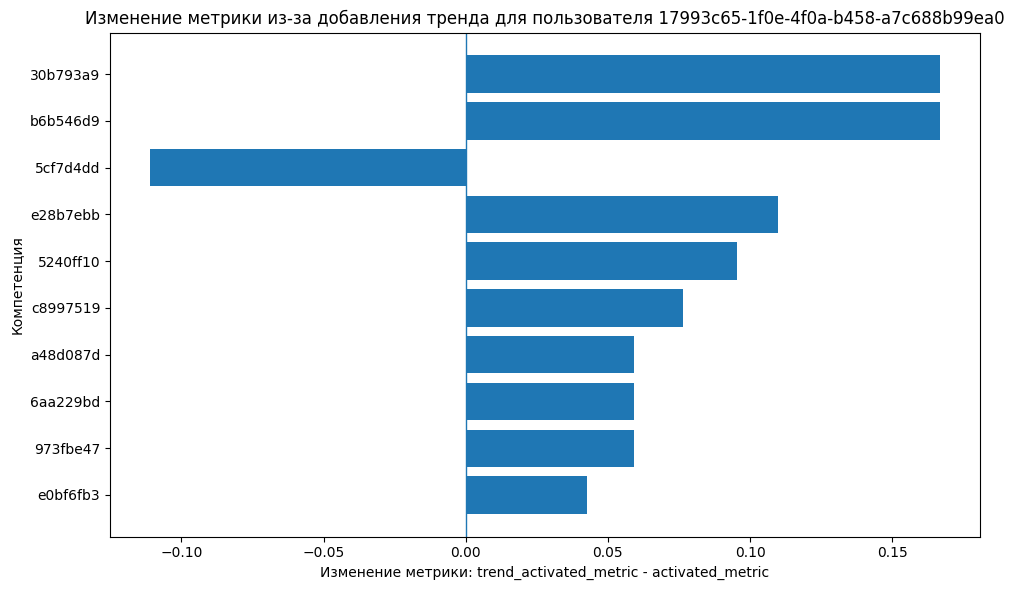

,user_id,competence_id,activated_metric,competence_trend,trend_activated_metric,delta
268,17993c65-1f0e-4f0a-b458-a7c688b99ea0,30b793a9-7275-40f1-9b91-6aed9314431d,0.875000,0.636182,1.041998,0.166998
925,17993c65-1f0e-4f0a-b458-a7c688b99ea0,b6b546d9-93fe-4eae-a0d9-20a263004945,0.875000,0.636182,1.041998,0.166998
465,17993c65-1f0e-4f0a-b458-a7c688b99ea0,5cf7d4dd-1c3f-4fb7-821c-6d4aa6df09aa,0.521739,-0.710569,0.410520,-0.111219
1164,17993c65-1f0e-4f0a-b458-a7c688b99ea0,e28b7ebb-d852-472a-8b46-99621bf850d1,0.714286,0.513405,0.824301,0.110015
398,17993c65-1f0e-4f0a-b458-a7c688b99ea0,5240ff10-72b6-4f5f-bf02-7b0c197d3c07,0.888889,0.358364,0.984453,0.095564
1060,17993c65-1f0e-4f0a-b458-a7c688b99ea0,c8997519-69fd-4adc-ab1d-d08163cf35bd,0.777778,0.327338,0.854157,0.076379
854,17993c65-1f0e-4f0a-b458-a7c688b99ea0,a48d087d-9104-45cb-ae04-d40aba5b883d,0.857143,0.230147,0.916324,0.059181
560,17993c65-1f0e-4f0a-b458-a7c688b99ea0,6aa229bd-a74f-43ae-b38d-c05a0f694f01,0.857143,0.230147,0.916324,0.059181
820,17993c65-1f0e-4f0a-b458-a7c688b99ea0,973fbe47-875d-433e-af35-bf61a7b933de,0.857143,0.230147,0.916324,0.059181
1140,17993c65-1f0e-4f0a-b458-a7c688b99ea0,e0bf6fb3-c7cf-47af-8f34-aa79a7837321,0.500000,0.285229,0.542784,0.042784


In [ ]:
import matplotlib.pyplot as plt

viz_df = agg_long.copy()

viz_df["delta"] = (
    viz_df["trend_activated_metric"]
    - viz_df["activated_metric"]
)

viz_df["abs_delta"] = viz_df["delta"].abs()

sample_user = (
    viz_df
    .groupby("user_id")["abs_delta"]
    .sum()
    .sort_values(ascending=False)
    .index[0]
)

user_comp = (
    viz_df[viz_df["user_id"] == sample_user]
    .sort_values("abs_delta", ascending=False)
    .head(10)
    .copy()
)

labels = user_comp["competence_id"].astype(str).str[:8]

plt.figure(figsize=(10, 6))

plt.barh(
    labels,
    user_comp["delta"]
)

plt.axvline(0, linewidth=1)

plt.gca().invert_yaxis()
plt.title(f"Изменение метрики из-за добавления тренда для пользователя {sample_user}")
plt.xlabel("Изменение метрики: trend_activated_metric - activated_metric")
plt.ylabel("Компетенция")
plt.tight_layout()
plt.show()

display(user_comp[[
    "user_id",
    "competence_id",
    "activated_metric",
    "competence_trend",
    "trend_activated_metric",
    "delta"
]])

**Идея задачи:**

> Добавить в рекомендательную систему параметр тренда школьника по компетенциям.

Для этого я использовал две выгрузки данных с разницей примерно в неделю - за 31 марта и 9 апреля (`user_competences` за разные даты) и для каждой пары `user_id + competence_id` («пользователь + компетенция») посчитал изменение вероятности владения компетенцией:

`competence_trend = probability_new - probability_old`

Это и есть тренд: вырос - хорошо, упал - интересно, не изменился - ладно, учтём.

Дальшеп я чуть чуть скорректировал имеющуюся метрику `activated_metric`, на которой обучается ALS (которую сделал Андрей) с учётом тренда по формуле:

`trend_activated_metric = activated_metric * (1 + alpha * competence_trend)`,

где `alpha = 0.3`.

Если компетенция растёт - её вес чуть увеличивается. Если падает - немного снижается. Если без изменений - всё остаётся как было. Коэффициент 0.3 я подбирал так, чтобы тренд влиял заметно, но не перекрывал исходную метрику.

И только после этого на обновлённой матрице я уже обучал ALS. В итоге получились рекомендации компетенций для каждого из 33 пользователей, а потом они перевелись на уровень конкретных микромодулей через Jaccard-схожесть между рекомендованными компетенциями и тем, что покрывает каждый модуль.

По результатам:
- матрица `user × competence` имеет размер 33 × 98;
- тренд был найден для 29 пользователей и 92 компетенций;
- ненулевой тренд повлиял на 167 строк, то есть примерно на 13.2% пар пользователь–компетенция

Из 1261 пары «пользователь + компетенция» тренд реально что-то изменил примерно в 13% случаев - за неделю скорее всего много не поменяется. Но именно там, где динамика есть, система теперь её учитывает.